In [4]:
from IPython.display import Markdown, display

text = """
# Лабораторна робота №4

**Виконав:** студент групи ОІ-32 Прокопів Юрій  
**Прийняла:** асистентка Нарушинська О.О.

### Тема:
Розгортання моделі машинного навчання

**Варіант – 7**

---

## Опис проєкту

Проєкт реалізує повноцінний ML-сервіс для клініки BreathWell, що дозволяє:
- Тренувати модель на даних пацієнтів з бази даних
- Робити передбачення для нових пацієнтів через HTTP API
- Зберігати всі передбачення та метрики для подальшого аналізу
- Моніторити якість моделі в реальному часі

---

## Структура проєкту

```
gulp/lab4/
├── main.py                    # Головний FastAPI додаток
├── endpoints/
│   ├── training.py           # Модуль тренування моделі
│   └── inference.py          # Модуль передбачення
├── database/
│   ├── database.py           # Підключення до БД
│   └── config.py             # Конфігурація
├── models/                    # Збережені моделі (.pkl)
└── test_api.py               # Тестування API
```

---

## Логіка розділення даних

При тренуванні моделі через `/train-model` виконується:

1. **Завантаження**: Всі дані з таблиці `asthma_patients_data` завантажуються в пам'ять
2. **Розділення 90:10**: 
   - 90% даних → тренування моделі
   - 10% даних → резерв для тестування (new_input)
3. **Стратифікація**: Використовується `stratify=y` для збереження пропорцій класів
4. **Збереження**: Модель зберігається у `models/model_latest.pkl`

---

## Які колонки зберігаються в predictions та inference_inputs

### Таблиця `predictions`
Зберігає результати всіх передбачень моделі:

| Колонка | Тип | Опис |
|---------|-----|------|
| `id` | SERIAL | Унікальний ідентифікатор |
| `patientid` | BIGINT | ID пацієнта |
| `true_label` | INTEGER | Справжній діагноз (NULL для inference) |
| `predicted_label` | INTEGER | Передбачений діагноз (0 або 1) |
| `predicted_proba` | FLOAT | Ймовірність астми (0.0-1.0) |
| `model_name` | VARCHAR(255) | Назва моделі |
| `source` | VARCHAR(50) | Джерело: "train" або "inference" |
| `created_at` | TIMESTAMP | Час створення запису |

**Приклад даних:**
```
patientid | true_label | predicted_label | predicted_proba | source
----------|------------|-----------------|-----------------|----------
5034      | 0          | 0               | 0.35            | train
1001      | NULL       | 1               | 0.72            | inference
```

### Таблиця `inference_inputs`
Зберігає всі вхідні параметри від користувачів:

| Колонка | Тип | Опис |
|---------|-----|------|
| `id` | SERIAL | Унікальний ідентифікатор |
| `patientid` | BIGINT | ID пацієнта (опціонально) |
| `input_data` | JSONB | Всі параметри пацієнта у форматі JSON |
| `model_name` | VARCHAR(255) | Назва моделі |
| `created_at` | TIMESTAMP | Час запиту |

**Приклад `input_data`:**
```json
{
  "age": 0.5,
  "bmi": -1.58,
  "smoking": -0.41,
  "wheezing": 0.3,
  "lungfunctionfev1": 0.8,
  ...
}
```

### Плани на майбутнє:
Загальними планами на майбутнє є інтеграція з медичною системою, тобто попередження лікарів про високий ризик астми на основі передбачень моделі історія передбачень для пацієнтів і тд. 
Щодо моделі логічно що було б непогано з часом покращувати точність оцінки цього ризику астим на більшій кількості даних.



## Висновки

В результаті виконання лабораторної роботи було створено повноцінний ML-сервіс, що дозволяє простим людям бачити як працює модель та використовувати функцію предікшену для перевірки чи буде в людини астма чи ні.
Така відкритість дозволяє залучити більше користувачів та можливо покращити модель за допомогою її тренування.
Загалом протягом виконання лабораторної роботи я навчився робити те що ніколи не робив раніше, а точніше створювати власну апішку для моделі та робити різного типу маніпуляції над нею
Це як на мене доволі непоганий досвід навіть попри те що моя модель трішки so so...

"""

display(Markdown(text))


# Лабораторна робота №4

**Виконав:** студент групи ОІ-32 Прокопів Юрій  
**Прийняла:** асистентка Нарушинська О.О.

### Тема:
Розгортання моделі машинного навчання

**Варіант – 7**

---

## Опис проєкту

Проєкт реалізує повноцінний ML-сервіс для клініки BreathWell, що дозволяє:
- Тренувати модель на даних пацієнтів з бази даних
- Робити передбачення для нових пацієнтів через HTTP API
- Зберігати всі передбачення та метрики для подальшого аналізу
- Моніторити якість моделі в реальному часі

---

## Структура проєкту

```
gulp/lab4/
├── main.py                    # Головний FastAPI додаток
├── endpoints/
│   ├── training.py           # Модуль тренування моделі
│   └── inference.py          # Модуль передбачення
├── database/
│   ├── database.py           # Підключення до БД
│   └── config.py             # Конфігурація
├── models/                    # Збережені моделі (.pkl)
└── test_api.py               # Тестування API
```

---

## Логіка розділення даних

При тренуванні моделі через `/train-model` виконується:

1. **Завантаження**: Всі дані з таблиці `asthma_patients_data` завантажуються в пам'ять
2. **Розділення 90:10**: 
   - 90% даних → тренування моделі
   - 10% даних → резерв для тестування (new_input)
3. **Стратифікація**: Використовується `stratify=y` для збереження пропорцій класів
4. **Збереження**: Модель зберігається у `models/model_latest.pkl`

---

## Які колонки зберігаються в predictions та inference_inputs

### Таблиця `predictions`
Зберігає результати всіх передбачень моделі:

| Колонка | Тип | Опис |
|---------|-----|------|
| `id` | SERIAL | Унікальний ідентифікатор |
| `patientid` | BIGINT | ID пацієнта |
| `true_label` | INTEGER | Справжній діагноз (NULL для inference) |
| `predicted_label` | INTEGER | Передбачений діагноз (0 або 1) |
| `predicted_proba` | FLOAT | Ймовірність астми (0.0-1.0) |
| `model_name` | VARCHAR(255) | Назва моделі |
| `source` | VARCHAR(50) | Джерело: "train" або "inference" |
| `created_at` | TIMESTAMP | Час створення запису |

**Приклад даних:**
```
patientid | true_label | predicted_label | predicted_proba | source
----------|------------|-----------------|-----------------|----------
5034      | 0          | 0               | 0.35            | train
1001      | NULL       | 1               | 0.72            | inference
```

### Таблиця `inference_inputs`
Зберігає всі вхідні параметри від користувачів:

| Колонка | Тип | Опис |
|---------|-----|------|
| `id` | SERIAL | Унікальний ідентифікатор |
| `patientid` | BIGINT | ID пацієнта (опціонально) |
| `input_data` | JSONB | Всі параметри пацієнта у форматі JSON |
| `model_name` | VARCHAR(255) | Назва моделі |
| `created_at` | TIMESTAMP | Час запиту |

**Приклад `input_data`:**
```json
{
  "age": 0.5,
  "bmi": -1.58,
  "smoking": -0.41,
  "wheezing": 0.3,
  "lungfunctionfev1": 0.8,
  ...
}
```

### Плани на майбутнє:
Загальними планами на майбутнє є інтеграція з медичною системою, тобто попередження лікарів про високий ризик астми на основі передбачень моделі історія передбачень для пацієнтів і тд. 
Щодо моделі логічно що було б непогано з часом покращувати точність оцінки цього ризику астим на більшій кількості даних.



## Висновки

В результаті виконання лабораторної роботи було створено повноцінний ML-сервіс, що дозволяє простим людям бачити як працює модель та використовувати функцію предікшену для перевірки чи буде в людини астма чи ні.
Така відкритість дозволяє залучити більше користувачів та можливо покращити модель за допомогою її тренування.
Загалом протягом виконання лабораторної роботи я навчився робити те що ніколи не робив раніше, а точніше створювати власну апішку для моделі та робити різного типу маніпуляції над нею
Це як на мене доволі непоганий досвід навіть попри те що моя модель трішки so so...



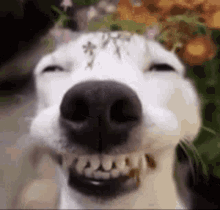